# Project 1 — Welding Defect Object Detection (YOLOv8)
This notebook covers **Task 1 (Data Preparation)** and **Task 2 (Model Development)**.

 Outputs you will use later:
- `data_local.yaml`
- Training curves: `runs/.../results.png`
- Trained weights: `runs/.../weights/best.pt`


## 0) Setup
**Goal:** install dependencies and set global config (paths, seeds, device).

In [1]:
# # --- 1. CLEANUP (Prevent version mixing) ---
!pip uninstall -y numpy scipy protobuf tensorboard ultralytics albumentations

# # --- 2. INSTALL BASE (Strict Pinning) ---
# # We install numpy, scipy, and protobuf TOGETHER to force resolution
!pip install "numpy<2.0" "scipy<1.14" "protobuf<=3.20.1" "tensorboard<2.14"

# # --- 3. INSTALL REPO DEPENDENCIES ---
# # Use --no-deps for albumentations to stop it from fighting with NumPy
!pip install "albumentations==2.0.8" --no-deps
# # FIX: Corrected username from 'sovit-23' to 'sovit-123'
!pip install git+https://github.com/sovit-123/vision_transformers.git
!pip install "pycocotools==2.0.8" "sahi" "torchinfo" "deep-sort-realtime"

# # --- 4. INSTALL ULTRALYTICS (Safely) ---
# # We explicitly tell pip NOT to upgrade numpy while installing ultralytics
!pip install "ultralytics>=8.3.70" "flash-attn" --no-build-isolation

# # --- 5. RE-INSTALL VISUALIZATION LIBS ---
# # Ensure these match the old NumPySSA
!pip install "matplotlib" "seaborn" "pandas"

print("Installation Complete. PLEASE RESTART THE RUNTIME NOW.")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: protobuf 3.20.1
Uninstalling protobuf-3.20.1:
  Successfully uninstalled protobuf-3.20.1
Found existing installation: tensorboard 2.13.0
Uninstalling tensorboard-2.13.0:
  Successfully uninstalled tensorboard-2.13.0
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached protobuf-3.20.1-py2.py3-none-any.whl.metadata (720 bytes)
  Using cached tensorboard-2.13.0-py3-none-any.whl.metadata (1.8 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl (46.2 MB)
Using cached protobuf-3.20.1-py2.py3-none-any.whl (162 kB)
Using cached tensorboard-2.13.0-py3-none-any.whl (5.6 MB)

   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.1 which is incompatible.
tensorflow 2.20.0 requires tensorboard~=2.20.0, but you have tensorboard 2.13.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\golla\\AppData\\Local\\Temp\\pip-install-b0u3abpq\\flash-attn_18a4d391f02140c5bed9a07d44d804d4\\csrc\\composable_kernel\\library\\include\\ck\\library\\tensor_operation_instance\\gpu\\grouped_conv_bwd_weight\\device_grouped_conv_bwd_weight_two_stage_xdl_instance.hpp'


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Installation Complete. PLEASE RESTART THE RUNTIME NOW.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
import ultralytics, torch, platform
print("Ultralytics:", ultralytics.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", platform.python_version())


Ultralytics: 8.3.246
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Python: 3.10.19


In [3]:
import os, shutil, random, glob
from pathlib import Path

# Change this to where you want to store your working dataset
BASE_DIR = "/kaggle/input/welding-defect-object-detection/The Welding Defect Dataset - v2/The Welding Defect Dataset - v2"
WORK_DIR = Path("/kaggle/working")  # Kaggle
# WORK_DIR = Path("/content")       # Colab

DATASET_DIR = WORK_DIR / "datasets" / "weld"
for p in [
    DATASET_DIR/"images/train", DATASET_DIR/"images/val", DATASET_DIR/"images/test",
    DATASET_DIR/"labels/train", DATASET_DIR/"labels/val", DATASET_DIR/"labels/test",
]:
    p.mkdir(parents=True, exist_ok=True)

print("Created:", DATASET_DIR)


Created: \kaggle\working\datasets\weld


pip install ultralytics opencv-python matplotlib scikit-learn pyyaml


## 1) Inspect dataset structure + class names
**Goal:** prove dataset is available and read class names from `data.yaml`.

In [10]:
from pathlib import Path

DATA_ROOT = Path(r"C:\Users\golla\Downloads\archive\The Welding Defect Dataset\The Welding Defect Dataset")  # <-- change
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])

# Check expected folders
for split in ["train", "valid", "test"]:
    print(split, "images:", (DATA_ROOT/split/"images").exists(),
                "labels:", (DATA_ROOT/split/"labels").exists())

DATA_YAML = DATA_ROOT / "data.yaml"
print("data.yaml exists:", DATA_YAML.exists(), DATA_YAML)


DATA_ROOT exists: True
Contents: ['data.yaml', 'data_fixed.yaml', 'test', 'train', 'valid']
train images: True labels: True
valid images: True labels: True
test images: True labels: True
data.yaml exists: True C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data.yaml


In [12]:
import yaml

cfg = yaml.safe_load((DATA_ROOT/"data.yaml").read_text())
print("data.yaml content:\n", cfg)

names = cfg.get("names")
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in sorted(names)]
else:
    CLASS_NAMES = names

print("CLASS_NAMES:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))


data.yaml content:
 {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['Bad Weld', 'Good Weld', 'Defect']}
CLASS_NAMES: ['Bad Weld', 'Good Weld', 'Defect']
Number of classes: 3


## 2) Dataset counts (train/valid/test)
**Goal:** print number of images + labels per split.

In [13]:
from collections import Counter

def count_images(folder):
    img_dir = DATA_ROOT/folder/"images"
    exts = ["*.jpg", "*.jpeg", "*.png"]
    count = 0
    for e in exts:
        count += len(list(img_dir.glob(e)))
    return count

def count_labels(folder):
    lab_dir = DATA_ROOT/folder/"labels"
    return len(list(lab_dir.glob("*.txt")))

for split in ["train", "valid", "test"]:
    n_img = count_images(split)
    n_lab = count_labels(split)
    print(f"{split:5s} -> images: {n_img}, labels: {n_lab}")


train -> images: 835, labels: 835
valid -> images: 176, labels: 176
test  -> images: 74, labels: 74


## 3) Visualize bounding boxes (data integrity)
**Goal:** show sample images with YOLO boxes drawn.

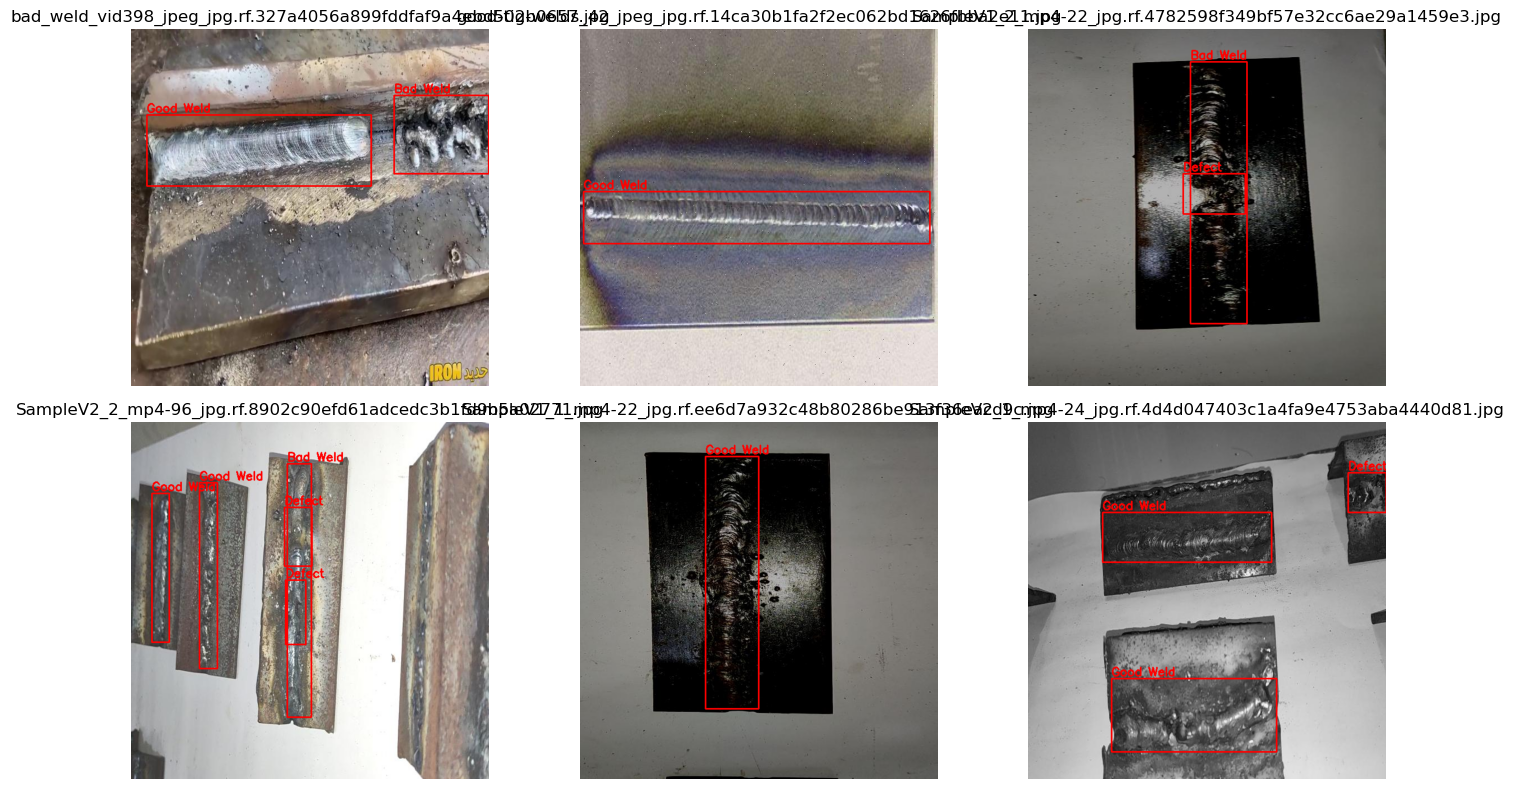

In [14]:
import random
import cv2
import matplotlib.pyplot as plt

def yolo_to_xyxy(line, w, h):
    c, xc, yc, bw, bh = map(float, line.split())
    x1 = int((xc - bw/2) * w)
    y1 = int((yc - bh/2) * h)
    x2 = int((xc + bw/2) * w)
    y2 = int((yc + bh/2) * h)
    return int(c), x1, y1, x2, y2

def show_samples(split="train", n=6):
    img_dir = DATA_ROOT/split/"images"
    lab_dir = DATA_ROOT/split/"labels"

    imgs = []
    for ext in ("*.jpg","*.jpeg","*.png"):
        imgs += list(img_dir.glob(ext))
    random.shuffle(imgs)
    imgs = imgs[:n]

    plt.figure(figsize=(14, 8))
    for i, img_path in enumerate(imgs, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lab_path = lab_dir/(img_path.stem + ".txt")
        if lab_path.exists() and lab_path.read_text().strip():
            for line in lab_path.read_text().strip().splitlines():
                cls, x1, y1, x2, y2 = yolo_to_xyxy(line, w, h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
                cv2.putText(img, name, (x1, max(0,y1-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()

show_samples("train", 6)


In [15]:
!pip -q install ultralytics



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4) Create `data_local.yaml`
**Goal:** ensure paths inside YAML point to your local dataset (Windows paths), not Kaggle paths.

In [16]:
import yaml

data = yaml.safe_load((DATA_ROOT/"data.yaml").read_text())

# Force local dataset path
data["path"] = str(DATA_ROOT)

# Ensure split paths are correct (most datasets use these)
data["train"] = "train/images"
data["val"]   = "valid/images"
data["test"]  = "test/images"

# Ensure names exist
data["names"] = CLASS_NAMES
data["nc"] = len(CLASS_NAMES)

(DATA_ROOT/"data_local.yaml").write_text(yaml.safe_dump(data, sort_keys=False))
print(" Wrote:", DATA_ROOT/"data_local.yaml")
print((DATA_ROOT/"data_local.yaml").read_text())


 Wrote: C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data_local.yaml
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- Bad Weld
- Good Weld
- Defect
path: C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect
  Dataset



## 5) Train YOLOv8s (Task 2)
**Goal:** train a detector, track validation mAP@0.5, and save best weights.

In [17]:
from ultralytics import YOLO
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolov8s.pt")  # YOLOv8 small

results = model.train(
    data=str(DATA_ROOT/"data_local.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,      # if out-of-memory, change to 8 or 4
    seed=42,
    project="runs",
    name="weld_yolov8s_640"
)


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Ultralytics 8.3.246  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data_local.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mul

In [19]:
from pathlib import Path

# Search for best.pt inside your current project folder
root = Path(".").resolve()
best_files = list(root.rglob("best.pt"))

print("Current notebook folder:", root)
print("Found best.pt files:")
for p in best_files:
    print(" -", p)


Current notebook folder: C:\Users\golla\Welding Project
Found best.pt files:
 - C:\Users\golla\Welding Project\runs\detect\train2\weights\best.pt
 - C:\Users\golla\Welding Project\runs\weld_yolov8s_640\weights\best.pt


In [20]:
from pathlib import Path

RUNS_DIR = Path(r"C:\Users\golla\Welding Project\runs")
best_files = list(RUNS_DIR.rglob("best.pt"))

print("Found best.pt files:")
for p in best_files:
    print(" -", p)


Found best.pt files:
 - C:\Users\golla\Welding Project\runs\detect\train2\weights\best.pt
 - C:\Users\golla\Welding Project\runs\weld_yolov8s_640\weights\best.pt


In [21]:
from ultralytics import YOLO

BEST_MODEL = r"C:\Users\golla\Welding Project\runs\detect\train2\weights\best.pt"  # <-- paste your exact path here
model = YOLO(BEST_MODEL)

print(" Model loaded successfully!")


 Model loaded successfully!
